# Student Monthly Expense Pattern Classifier
### EDA → Feature Engineering → Baselines → Tuned Models → Evaluation

**Goal:** learn patterns in a student's monthly income and category-wise spending using supervised learning.

The original notebook also trained models with `expense_income_ratio` as an input. **Those ratio-input models have been removed.**
The remaining model uses only the underlying income, spending categories, age, and categorical demographic features.

`Tuition Fees`, `Rent/Room Accommodation`, and the dataset's own `Final Monthly Expense` column are excluded from the model features.

## 1. Imports & Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, json

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                              accuracy_score, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance
from scipy.optimize import minimize

np.random.seed(42)
sns.set_style("whitegrid")
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
print("Libraries loaded succesfully")


Libraries loaded succesfully


## 2. Load the Dataset

In [2]:
df = pd.read_csv("student_data.csv")
print("Shape:", df.shape)
df.head()


FileNotFoundError: [Errno 2] No such file or directory: 'student_data.csv'

In [ ]:
print(df.dtypes)
print()
print("Missing values per column:")
print(df.isnull().sum().sum(), "total missing values")
print()
print("Duplicate rows:", df.duplicated().sum())


Name                                     str
Age                                    int64
Gender                                   str
Current educational level                str
Monthly Income                         int64
Rent/Room Accommodation                int64
Utilities                              int64
Groceries                              int64
Dining Out/Eating Outside              int64
Public Transportation                  int64
Fuel/Car Maintenance                   int64
Tuition Fees                           int64
Books and Supplies                     int64
Online Courses/Subscriptions           int64
Clothing/Shoes                         int64
Entertainment                          int64
Health Insurance/Medical Expenses      int64
Gym Memberships/Physical Activities    int64
Mobile Phone/Internet Bill             int64
Final Monthly Expense                  int64
dtype: object

Missing values per column:
0 total missing values

Duplicate rows: 0


## 3. Feature Engineering: Building the 7 Spending Categories

The raw expense columns (excluding Tuition Fees & Rent) are grouped into the 7 categories we care about.
A `total_expense` feature is also calculated for analysis.

The income-to-expense ratio is retained only for constructing the existing risk labels; it is **never passed to any model**.

In [ ]:
cat_map = {
    'healthcare':   ['Health Insurance/Medical Expenses'],
    'shopping':     ['Clothing/Shoes'],
    'education':    ['Books and Supplies', 'Online Courses/Subscriptions'],
    'transport':    ['Public Transportation', 'Fuel/Car Maintenance'],
    'utilities':    ['Utilities', 'Mobile Phone/Internet Bill'],
    'food_dining':  ['Groceries', 'Dining Out/Eating Outside'],
    'entertainment':['Entertainment', 'Gym Memberships/Physical Activities'],
}
category_cols = list(cat_map.keys())

for cat, cols in cat_map.items():
    df[cat] = df[cols].sum(axis=1)

df['total_expense'] = df[category_cols].sum(axis=1)
df['expense_income_ratio'] = df['total_expense'] / df['Monthly Income']

df[['Monthly Income'] + category_cols + ['total_expense']].describe().T

,count,mean,std,min,25%,50%,75%,max
Monthly Income,200.0,906.090,215.835881,503.0,742.50,911.0,1087.50,1292.0
healthcare,200.0,108.425,51.388992,20.0,67.00,108.0,152.00,198.0
shopping,200.0,82.765,37.554513,20.0,52.75,82.5,117.00,148.0
education,200.0,123.560,40.333489,33.0,96.75,124.0,153.25,209.0
transport,200.0,208.735,35.923911,128.0,181.00,209.5,234.00,282.0
utilities,200.0,103.115,15.261927,73.0,91.00,102.0,116.25,138.0
food_dining,200.0,183.525,48.351408,74.0,150.75,183.5,219.00,286.0
entertainment,200.0,177.575,48.281777,68.0,145.75,180.5,212.25,285.0
total_expense,200.0,987.700,112.984812,729.0,909.00,991.0,1070.50,1359.0


## 4. Exploratory Data Analysis (EDA)

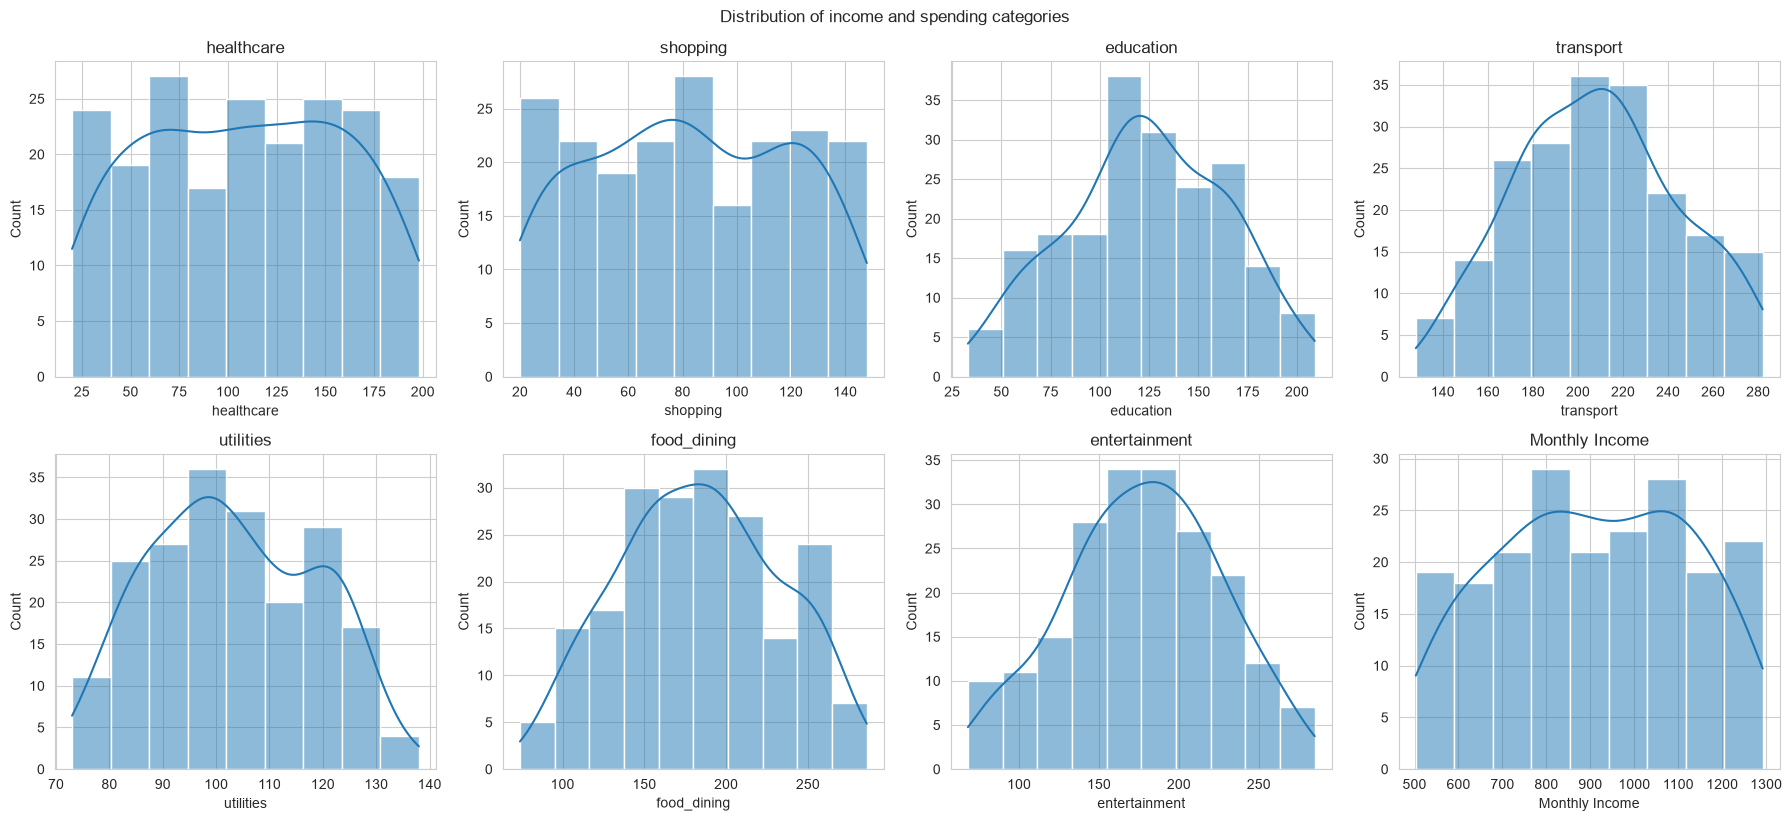

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, category_cols + ['Monthly Income']):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.suptitle("Distribution of income and spending categories", y=1.02)
plt.show()

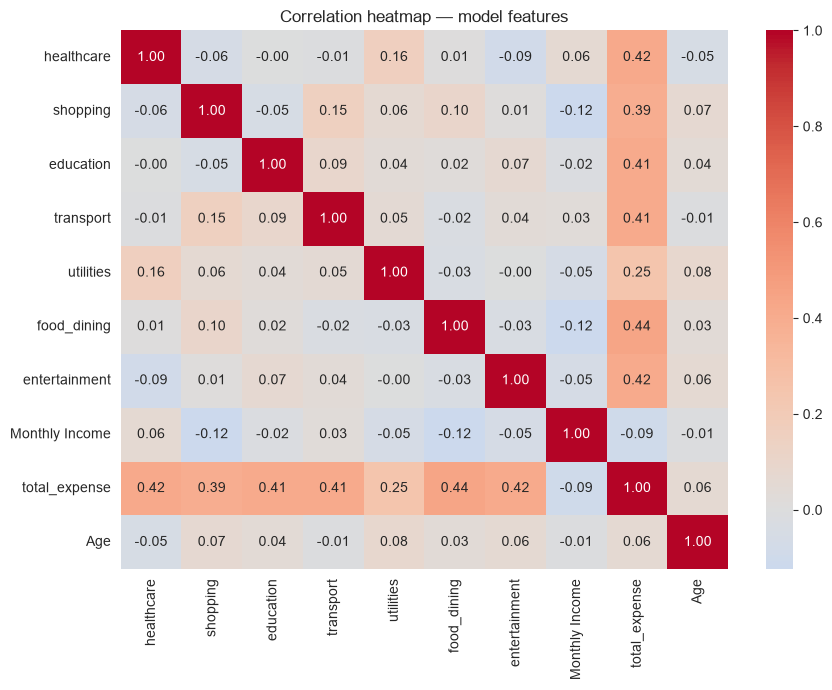

In [ ]:
plt.figure(figsize=(9, 7))
corr_cols = category_cols + ['Monthly Income', 'total_expense', 'Age']
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title("Correlation heatmap — model features")
plt.tight_layout()
plt.show()

In [ ]:
print("Gender distribution:")
print(df['Gender'].value_counts())
print()
print("Educational level distribution:")
print(df['Current educational level'].value_counts())


Gender distribution:
Gender
Male      106
Female     94
Name: count, dtype: int64

Educational level distribution:
Current educational level
Graduate         77
High School      75
Undergraduate    48
Name: count, dtype: int64


## 5. Outlier Detection (visual)

Boxplots make outliers immediately visible. We inspect income, the seven category expenses, and total expense.

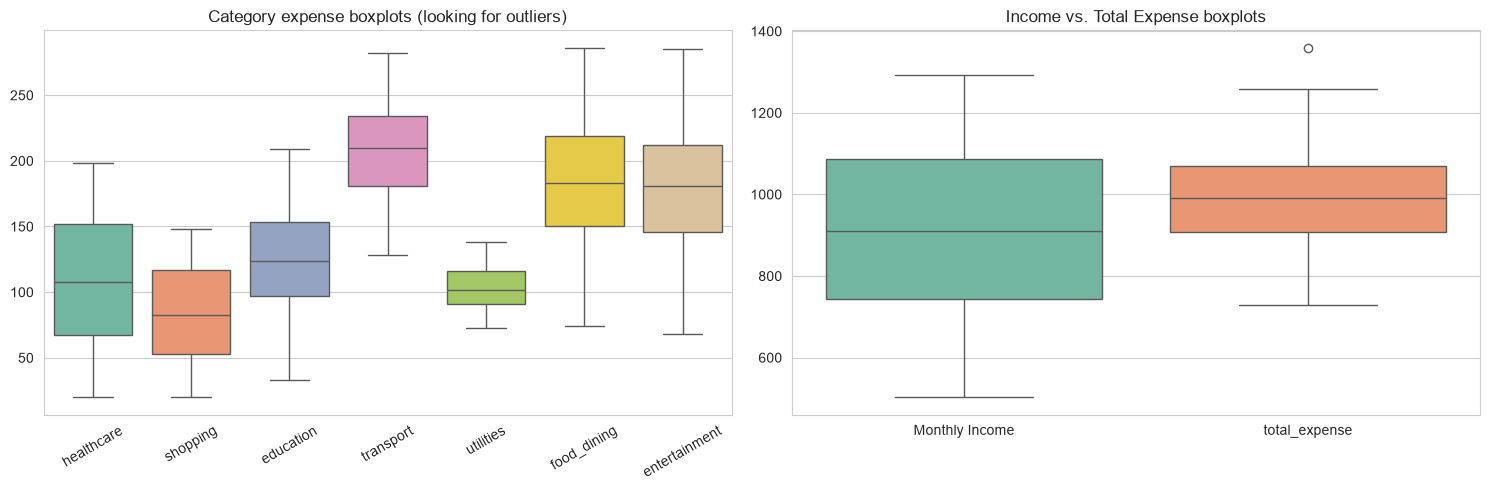

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=df[category_cols], ax=axes[0], palette='Set2')
axes[0].set_title("Category expense boxplots (looking for outliers)")
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df[['Monthly Income', 'total_expense']], ax=axes[1], palette='Set2')
axes[1].set_title("Income vs. Total Expense boxplots")

plt.tight_layout()
plt.show()


In [ ]:
def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

outlier_counts = {}
for col in category_cols + ['Monthly Income', 'total_expense']:
    lo, hi = iqr_bounds(df[col])
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    outlier_counts[col] = n_out
    print(f"{col:20s} IQR fence=[{lo:8.1f}, {hi:8.1f}]   outliers={n_out}")


healthcare           IQR fence=[   -60.5,    279.5]   outliers=0
shopping             IQR fence=[   -43.6,    213.4]   outliers=0
education            IQR fence=[    12.0,    238.0]   outliers=0
transport            IQR fence=[   101.5,    313.5]   outliers=0
utilities            IQR fence=[    53.1,    154.1]   outliers=0
food_dining          IQR fence=[    48.4,    321.4]   outliers=0
entertainment        IQR fence=[    46.0,    312.0]   outliers=0
Monthly Income       IQR fence=[   225.0,   1605.0]   outliers=0
total_expense        IQR fence=[   666.8,   1312.8]   outliers=1


## 6. Outlier Treatment (IQR Winsorization)

Every numeric column is capped to its 1.5x IQR fence. This dataset turned out to be
very clean (near-uniform synthetic distributions), so very little actually changes --
but the step is applied properly regardless, since real-world versions of this data
would likely have genuine outliers.


In [ ]:
def iqr_cap(series, k=1.5):
    lo, hi = iqr_bounds(series, k)
    return series.clip(lo, hi)

before = df[category_cols + ['Monthly Income', 'total_expense']].copy()

for col in category_cols + ['Monthly Income', 'total_expense']:
    df[col] = iqr_cap(df[col])

changed = (before != df[before.columns]).sum()
print("Values changed by capping, per column:")
print(changed)


Values changed by capping, per column:
healthcare        0
shopping          0
education         0
transport         0
utilities         0
food_dining       0
entertainment     0
Monthly Income    0
total_expense     1
dtype: int64


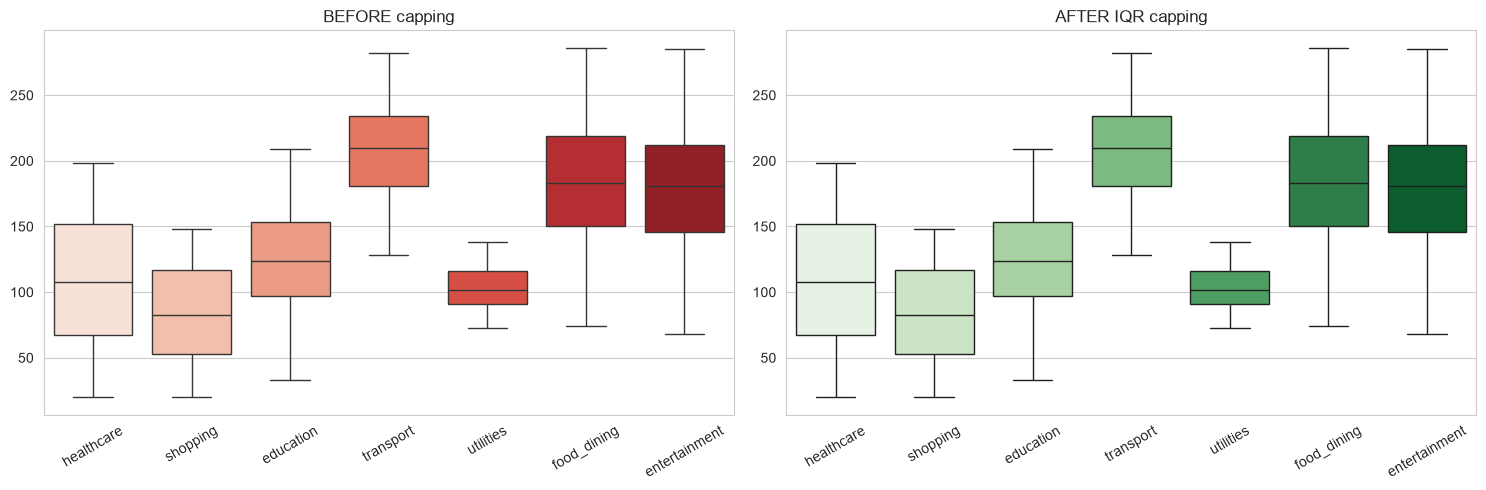

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=before[category_cols], ax=axes[0], palette='Reds')
axes[0].set_title("BEFORE capping")
axes[0].tick_params(axis='x', rotation=30)
sns.boxplot(data=df[category_cols], ax=axes[1], palette='Greens')
axes[1].set_title("AFTER IQR capping")
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


## 7. Target Label Construction

The original dataset has no ground-truth risk label, so the existing labels are engineered from `expense_income_ratio`.

**Important:** the ratio is used only to create `risk_label`; it is not included in the model's input features.
This means the remaining model is testing whether the underlying raw financial features can reproduce the engineered labels.

risk_label
worst       62
high        61
safe        40
critical    37
Name: count, dtype: int64

risk_label
worst       0.310
high        0.305
safe        0.200
critical    0.185
Name: proportion, dtype: float64


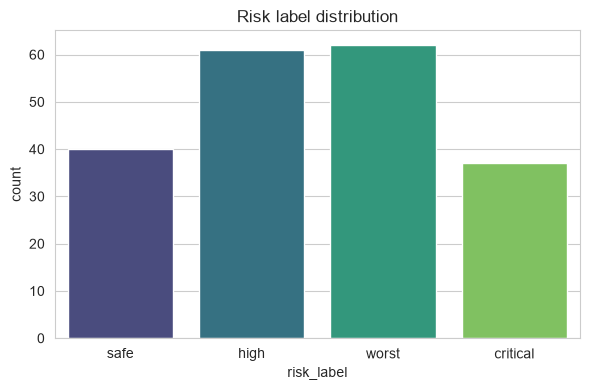

In [ ]:
# The ratio is used only to reproduce the notebook's existing target labels.
# It is NEVER included in X or passed to any model.
df['expense_income_ratio'] = df['total_expense'] / df['Monthly Income']

bins = [-np.inf, 0.85, 1.10, 1.50, np.inf]
labels = ['safe', 'high', 'worst', 'critical']
df['risk_label'] = pd.cut(df['expense_income_ratio'], bins=bins, labels=labels)

print(df['risk_label'].value_counts())
print()
print(df['risk_label'].value_counts(normalize=True).round(3))

plt.figure(figsize=(6, 4))
order = ['safe', 'high', 'worst', 'critical']
sns.countplot(x=df['risk_label'], order=order, palette='viridis')
plt.title("Risk label distribution")
plt.tight_layout()
plt.show()

## 8. Train / Test Split & Preprocessing

The model input deliberately excludes `expense_income_ratio`.

Numeric features: `Monthly Income`, the 7 spending categories, `total_expense`, and `Age`.
Categorical features: `Gender` and `Current educational level`.

In [ ]:
numeric_features = ['Monthly Income'] + category_cols + ['total_expense', 'Age']
categorical_features = ['Gender', 'Current educational level']

X = df[numeric_features + categorical_features].copy()
le = LabelEncoder()
y = le.fit_transform(df['risk_label'])

assert 'expense_income_ratio' not in X.columns

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

preprocess = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary'), categorical_features)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("Classes:", list(le.classes_))
print("Features passed to models:", list(X.columns))
print("Ratio included in X?", 'expense_income_ratio' in X.columns)
print("Train:", X_train.shape, " Test:", X_test.shape)

Classes: ['critical', 'high', 'safe', 'worst']
Features passed to models: ['Monthly Income', 'healthcare', 'shopping', 'education', 'transport', 'utilities', 'food_dining', 'entertainment', 'total_expense', 'Age', 'Gender', 'Current educational level']
Ratio included in X? False
Train: (160, 12)  Test: (40, 12)


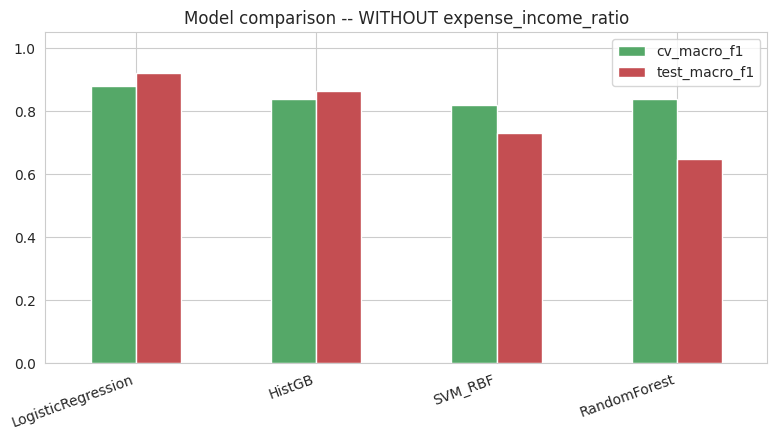

In [ ]:
## 9. Tuned Candidate Models

Four candidate classifiers are tuned with 5-fold stratified cross-validation using macro-F1.
No model receives `expense_income_ratio`.

In [ ]:
model_grids = {
    'LogisticRegression': (LogisticRegression(max_iter=2000),
        {'clf__C': [0.1, 1, 10]}),
    'RandomForest': (RandomForestClassifier(random_state=42),
        {'clf__n_estimators': [200, 400],
         'clf__max_depth': [6, 8, None],
         'clf__min_samples_leaf': [1, 2]}),
    'HistGB': (HistGradientBoostingClassifier(random_state=42),
        {'clf__max_iter': [100, 200],
         'clf__max_depth': [3, 5, None],
         'clf__learning_rate': [0.05, 0.1],
         'clf__l2_regularization': [0, 0.5]}),
    'SVM_RBF': (SVC(probability=True, random_state=42),
        {'clf__C': [1, 10, 50],
         'clf__gamma': ['scale', 'auto', 0.1]}),
}

results = {}
best_estimators = {}
for name, (clf, grid) in model_grids.items():
    pipe = Pipeline([('prep', preprocess), ('clf', clf)])
    gs = GridSearchCV(pipe, grid, cv=cv, scoring='f1_macro', n_jobs=-1)
    gs.fit(X_train, y_train)
    best_estimators[name] = gs.best_estimator_
    y_pred = gs.predict(X_test)
    results[name] = {
        'best_params': gs.best_params_,
        'cv_macro_f1': round(gs.best_score_, 4),
        'test_macro_f1': round(f1_score(y_test, y_pred, average='macro'), 4),
        'test_accuracy': round(accuracy_score(y_test, y_pred), 4),
    }
    print(f"{name:20s} CV macro-F1={results[name]['cv_macro_f1']:.4f}  "
          f"Test macro-F1={results[name]['test_macro_f1']:.4f}  "
          f"Test acc={results[name]['test_accuracy']:.4f}")
    print(f"   best params: {gs.best_params_}")

comparison_df = pd.DataFrame(results).T[['cv_macro_f1', 'test_macro_f1', 'test_accuracy']]
comparison_df = comparison_df.sort_values('cv_macro_f1', ascending=False)
comparison_df

LogisticRegression   CV macro-F1=0.8799  Test macro-F1=0.9213  Test acc=0.9250
   best params: {'clf__C': 10}
RandomForest         CV macro-F1=0.8399  Test macro-F1=0.6472  Test acc=0.6500
   best params: {'clf__max_depth': 8, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 400}
HistGB               CV macro-F1=0.8378  Test macro-F1=0.8643  Test acc=0.8500
   best params: {'clf__l2_regularization': 0, 'clf__learning_rate': 0.05, 'clf__max_depth': 5, 'clf__max_iter': 200}
SVM_RBF              CV macro-F1=0.8202  Test macro-F1=0.7289  Test acc=0.7250
   best params: {'clf__C': 10, 'clf__gamma': 'auto'}


,cv_macro_f1,test_macro_f1,test_accuracy
LogisticRegression,0.8799,0.9213,0.925
RandomForest,0.8399,0.6472,0.65
HistGB,0.8378,0.8643,0.85
SVM_RBF,0.8202,0.7289,0.725


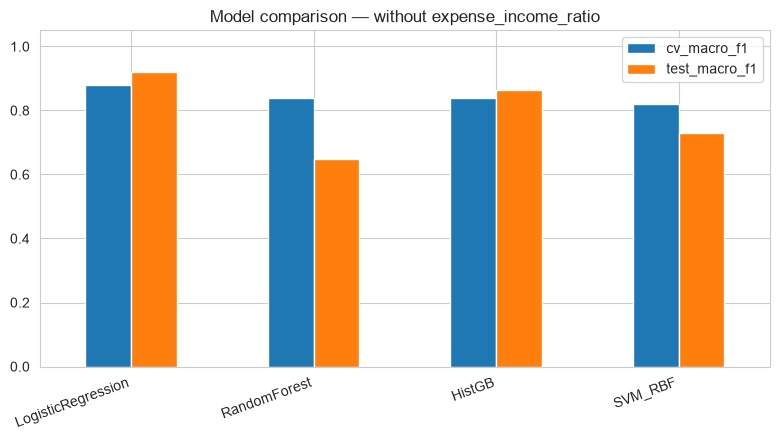

In [ ]:
plt.figure(figsize=(8, 4.5))
comparison_df[['cv_macro_f1', 'test_macro_f1']].plot(kind='bar', ax=plt.gca())
plt.title("Model comparison — without expense_income_ratio")
plt.ylim(0, 1.05)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
## 10. Final Model Evaluation

Select the model with the best cross-validated macro-F1, then evaluate once on the held-out test set.

SyntaxError: invalid syntax (1579961570.py, line 3)

In [ ]:
BEST_MODEL_NAME = comparison_df.index[0]
final_model = best_estimators[BEST_MODEL_NAME]
final_model.fit(X_train, y_train)
y_pred_final = final_model.predict(X_test)

print("Best model:", BEST_MODEL_NAME)
print(classification_report(y_test, y_pred_final, target_names=le.classes_))

Best model: LogisticRegression
              precision    recall  f1-score   support

    critical       1.00      0.88      0.93         8
        high       0.92      0.92      0.92        12
        safe       0.88      0.88      0.88         8
       worst       0.92      1.00      0.96        12

    accuracy                           0.93        40
   macro avg       0.93      0.92      0.92        40
weighted avg       0.93      0.93      0.92        40



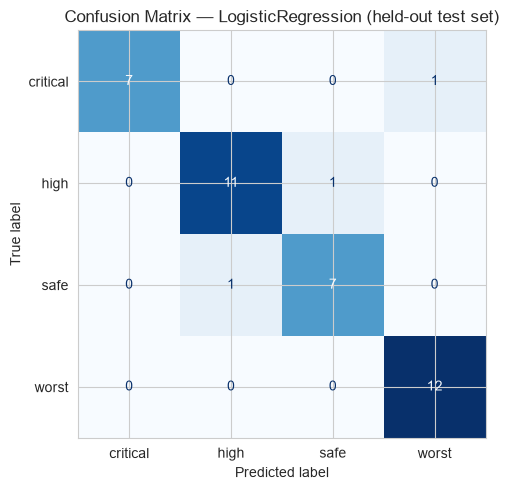

In [ ]:
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title(f"Confusion Matrix — {BEST_MODEL_NAME} (held-out test set)")
plt.tight_layout()
plt.show()

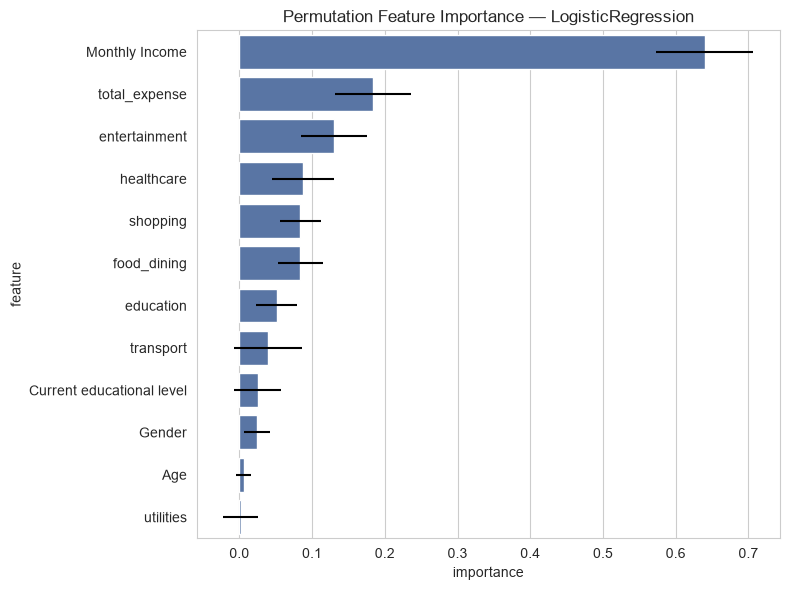

,feature,importance,std
0,Monthly Income,0.639579,0.067313
8,total_expense,0.184074,0.052616
7,entertainment,0.130646,0.045431
1,healthcare,0.087652,0.043103
2,shopping,0.083980,0.028350
6,food_dining,0.083487,0.030966
3,education,0.051408,0.028538
4,transport,0.039914,0.046773
11,Current educational level,0.025445,0.032406
10,Gender,0.024088,0.017608


In [ ]:
perm = permutation_importance(final_model, X_test, y_test, n_repeats=30,
                               random_state=42, scoring='f1_macro')
imp_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance': perm.importances_mean,
    'std': perm.importances_std
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=imp_df, x='importance', y='feature', color='#4C72B0', xerr=imp_df['std'])
plt.title(f"Permutation Feature Importance — {BEST_MODEL_NAME}")
plt.tight_layout()
plt.show()

imp_df

## 11. Save the Final Model

Only the model trained without `expense_income_ratio` as an input feature is saved.

In [ ]:
joblib.dump(final_model, 'final_model_no_ratio.joblib')
joblib.dump(le, 'label_encoder.joblib')

print("Saved:")
print(" - final_model_no_ratio.joblib (", BEST_MODEL_NAME, ")")
print(" - label_encoder.joblib")

Saved:
 - final_model_no_ratio.joblib ( LogisticRegression )
 - label_encoder.joblib


## 12. Summary

- All models that used `expense_income_ratio` as an input feature have been removed.
- The retained model uses income, category spending, total expense, age, gender, and education.
- `expense_income_ratio` is not present in `X`.
- **Caveat:** the current `risk_label` is still derived from the ratio because the raw dataset has no independent ground-truth risk label. So this is a no-ratio-input model, not a genuinely independent risk target.
- For the eventual FinTRAC product, this risk-classification setup should be replaced by a longitudinal spending-forecasting target when we obtain multi-month user transaction data.